# NG-SMR hydrogen NPV simulation

Run the Monte Carlo hydrogen model at 100,000 tH2/year. The notebook shows NPV, LNM, and LCOH distributions, NPV sign counts, and mean annual cost components. Greenfield European natural-gas steam-methane reforming without CCS. Net purchased electricity is approximately zero at 200 bar.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from hydrogen.hydrogen_npv_monte_carlo import (
    DEFAULT_RANDOM_SEED,
    DEFAULT_RETROFIT_BAU_MODE,
    DEFAULT_SAMPLE_SIZE,
    simulate_hydrogen_results,
)
from npv_summary import summarize_metric_signs
from npv_summary_plots import plot_financial_metric_distribution

pd.options.display.float_format = "{:,.3f}".format

In [2]:
TECHNOLOGY = "ng_smr"
SAMPLE_SIZE = DEFAULT_SAMPLE_SIZE
RANDOM_SEED = DEFAULT_RANDOM_SEED
RETROFIT_BAU_MODE = DEFAULT_RETROFIT_BAU_MODE

simulation = simulate_hydrogen_results(
    sample_size=SAMPLE_SIZE,
    random_seed=RANDOM_SEED,
    technologies=(TECHNOLOGY,),
    retrofit_bau_mode=RETROFIT_BAU_MODE,
)[TECHNOLOGY]
results = pd.DataFrame(simulation)
results.head()

,run_id,technology,technology_type,retrofit_bau_mode,annual_output_th2,lifetime_years,capex_eur_per_th2,fixed_opex_eur_per_th2,variable_opex_eur_per_th2,fuel_type,...,annual_electricity_cost_eur,annual_transport_and_storage_cost_eur,annual_emissions_cost_eur,annual_total_cost_eur,annual_net_cash_flow_eur,npv_eur,discounted_lifetime_output_th2,present_value_total_cost_eur,lcoh_eur_per_th2,levelized_net_margin_eur_per_th2
0,0,ng_smr,absolute,not_applicable,"100,000.000",25,"2,143.743",87.843,6.256,natural_gas,...,0.000,0.000,"72,000,000.000","236,025,367.332","513,974,632.668","5,272,189,836.686","1,067,477.619","2,733,892,304.755","2,561.077","4,938.923"
1,1,ng_smr,absolute,not_applicable,"100,000.000",25,"2,421.734",98.227,5.994,natural_gas,...,0.000,0.000,"72,000,000.000","256,218,040.963","493,781,959.037","5,028,838,485.489","1,067,477.619","2,977,243,655.952","2,789.046","4,710.954"
2,2,ng_smr,absolute,not_applicable,"100,000.000",25,"2,114.169",87.104,6.323,natural_gas,...,0.000,0.000,"72,000,000.000","293,553,076.198","456,446,923.802","4,661,051,838.306","1,067,477.619","3,345,030,303.136","3,133.584","4,366.416"
3,3,ng_smr,absolute,not_applicable,"100,000.000",25,"2,438.638",110.327,7.798,natural_gas,...,0.000,0.000,"72,000,000.000","260,912,267.404","489,087,732.596","4,977,038,250.841","1,067,477.619","3,029,043,890.600","2,837.571","4,662.429"
4,4,ng_smr,absolute,not_applicable,"100,000.000",25,"1,938.725",93.210,7.866,natural_gas,...,0.000,0.000,"72,000,000.000","305,851,860.206","444,148,139.794","4,547,309,495.002","1,067,477.619","3,458,772,646.440","3,240.136","4,259.864"


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
lcoh_eur_per_th2 = results["lcoh_eur_per_th2"]
levelized_net_margin_eur_per_th2 = results["levelized_net_margin_eur_per_th2"]

summary = pd.concat([
    npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename("NPV million EUR"),
    levelized_net_margin_eur_per_th2.describe(percentiles=[0.05, 0.5, 0.95]).rename("LNM EUR/tH2"),
    lcoh_eur_per_th2.describe(percentiles=[0.05, 0.5, 0.95]).rename("LCOH EUR/tH2"),
], axis=1)
npv_signs = summarize_metric_signs(npv_million_eur)
npv_sign_summary = pd.DataFrame([
    {"NPV category": "Non-negative (NPV >= 0)", "Count": npv_signs["non_negative_count"], "Share": npv_signs["non_negative_share"]},
    {"NPV category": "Negative (NPV < 0)", "Count": npv_signs["negative_count"], "Share": 1 - npv_signs["non_negative_share"]},
])
display(summary, npv_sign_summary)

,NPV million EUR,LNM EUR/tH2,LCOH EUR/tH2
count,"100,000.000","100,000.000","100,000.000"
mean,"5,052.441","4,733.065","2,766.935"
std,663.334,621.403,621.403
min,"2,787.902","2,611.672","1,560.036"
5%,"3,855.305","3,611.603","1,863.980"
50%,"5,123.104","4,799.261","2,700.739"
95%,"6,016.325","5,636.020","3,888.397"
max,"6,340.779","5,939.964","4,888.328"


,NPV category,Count,Share
0,Non-negative (NPV >= 0),100000,1.000
1,Negative (NPV < 0),0,0.000


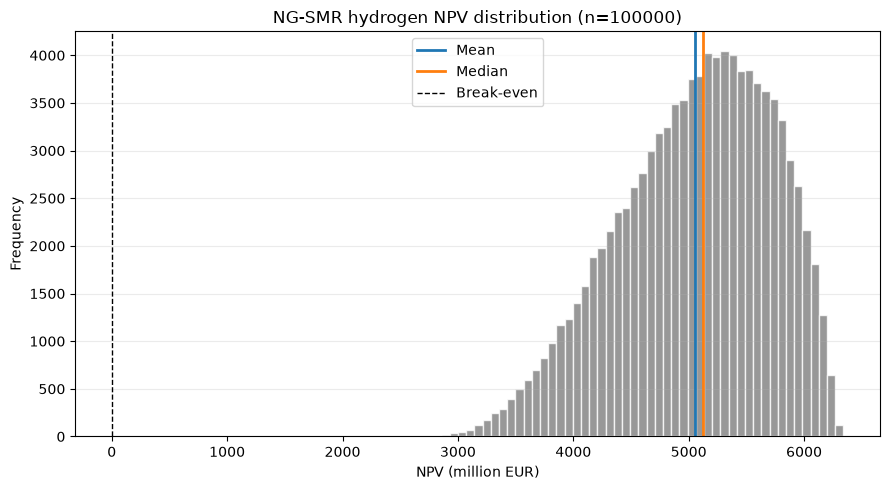

In [4]:
plot_financial_metric_distribution(
    npv_million_eur,
    title=f"NG-SMR hydrogen NPV distribution (n={SAMPLE_SIZE})",
    x_axis_label="NPV (million EUR)",
    color="tab:gray",
    show_break_even=True,
)
plt.show()

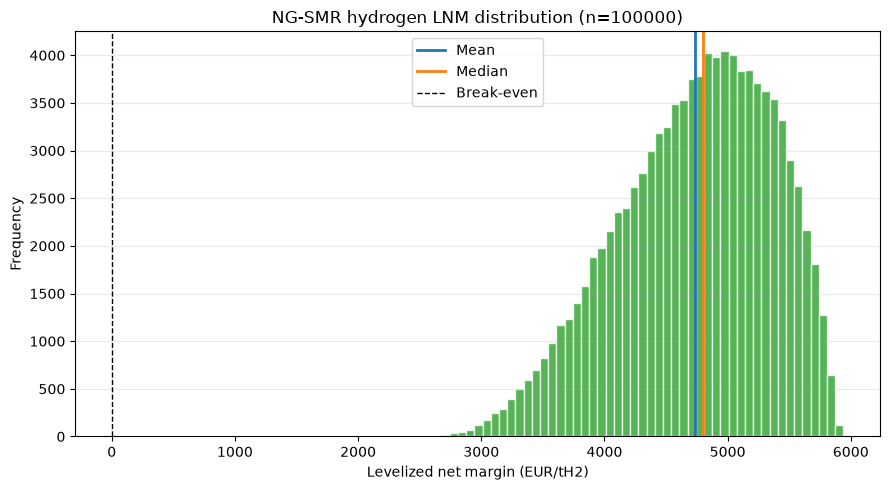

In [5]:
plot_financial_metric_distribution(
    levelized_net_margin_eur_per_th2,
    title=f"NG-SMR hydrogen LNM distribution (n={SAMPLE_SIZE})",
    x_axis_label="Levelized net margin (EUR/tH2)",
    color="tab:green",
    show_break_even=True,
)
plt.show()

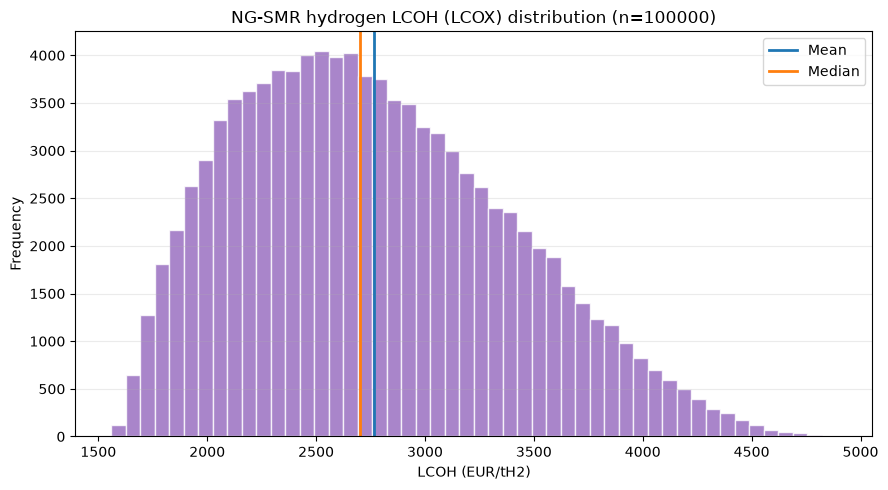

In [6]:
plot_financial_metric_distribution(
    lcoh_eur_per_th2,
    title=f"NG-SMR hydrogen LCOH (LCOX) distribution (n={SAMPLE_SIZE})",
    x_axis_label="LCOH (EUR/tH2)",
    color="tab:purple",
)
plt.show()

In [7]:
annual_columns = [
    "annual_revenue_eur",
    "annual_fixed_opex_eur",
    "annual_variable_opex_eur",
    "annual_natural_gas_cost_eur",
    "annual_biomethane_cost_eur",
    "annual_biomass_cost_eur",
    "annual_fuel_cost_eur",
    "annual_electricity_cost_eur",
    "annual_transport_and_storage_cost_eur",
    "annual_emissions_cost_eur",
    "annual_net_cash_flow_eur",
]
(results[annual_columns] / 1_000_000).mean().rename("Mean annual value, million EUR")

annual_revenue_eur                      750.000
annual_fixed_opex_eur                    10.196
annual_variable_opex_eur                  0.703
annual_natural_gas_cost_eur             172.167
annual_biomethane_cost_eur                0.000
annual_biomass_cost_eur                   0.000
annual_fuel_cost_eur                    172.167
annual_electricity_cost_eur               0.000
annual_transport_and_storage_cost_eur     0.000
annual_emissions_cost_eur                72.000
annual_net_cash_flow_eur                494.934
Name: Mean annual value, million EUR, dtype: float64